# Data Science Capstone, Adult Census Income: Data Preparation and EDA

This is the data preparation and EDA milestone for my capstone. The dataset is the Adult Census Income data from the UCI Machine Learning Repository, taken from the 1994 U.S. Census, with about 32,500 rows. The target is income, either more than 50K a year or 50K and under.

The whole project is built around three hypotheses, and I explore the data with those in mind rather than just making plots for their own sake:

H1: education level is a stronger driver of the over 50K prediction than hours worked.

H2: XGBoost is the fairest of the three models toward true high earners across nativity, with a smaller US-born vs foreign-born recall gap (on real >50K earners) than both Logistic Regression and the MLP

H3: XGBoost classifies better than both a logistic baseline and an MLP on PR-AUC and F1.

This notebook covers handling missing values, addressing class imbalance, feature engineering, showing the impact of preprocessing, summary statistics, visualizations, and patterns tied to my hypotheses.

## 1. Setup

In [1]:
# libraries and a navy and gold color scheme for the plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

NAVY = "#1f3a5f"
GOLD = "#c9a227"
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 2. Load the data into SQLite and pull it back

Following my project plan, the data goes into a small SQLite database first and everything after that reads from the database. The question mark missing values become NULLs when I load them, so they come back as NaN.

In [2]:
# read the raw csv once and save it into a sqlite database
raw = pd.read_csv("adult.csv", na_values="?", skipinitialspace=True)
conn = sqlite3.connect("adult.db")
raw.to_sql("adult", conn, if_exists="replace", index=False)
conn.close()
print("Saved adult.db with", len(raw), "rows")

Saved adult.db with 32561 rows


In [3]:
# pull the data back out of the database into the dataframe I will work with
conn = sqlite3.connect("adult.db")
df = pd.read_sql("SELECT * FROM adult", conn)
conn.close()
print("Shape:", df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,None,77053,HS-grad,9,Widowed,None,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,None,186061,Some-college,10,Widowed,None,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. First look at the data

In [4]:
# column types and non-null counts, where the missing values show up
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
# the column names before any cleaning
list(df.columns)

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education.num',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'native.country',
 'income']

## Handle missing values

First I check to see how much is missing in each column, then decide what to do with each one.

In [6]:
# how many values are missing per column and what percent that is
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percent": (df.isnull().mean() * 100).round(2)
})
missing[missing["missing"] > 0]

,missing,percent
workclass,1836,5.64
occupation,1843,5.66
native.country,583,1.79


Only three columns have missing values, and none of them are badly affected. Workclass is about 5.6 percent missing, occupation about 5.7 percent, and native country about 1.8 percent. All three are well under the level where dropping a column would make sense, and they are all categorical.

I will fill each of them with an explicit Unknown category rather than dropping the rows. Dropping every row with a missing value would throw away roughly 2,400 people, and the missingness is not random (people with a missing workclass often have a missing occupation too), so dropping them could bias the income analysis. An Unknown bucket keeps the rows and lets the model treat missingness as its own signal.

In [7]:
# fill the missing categorical values with an explicit Unknown category
for col in ["workclass", "occupation", "native.country"]:
    df[col] = df[col].fillna("Unknown")
print(df[["workclass", "occupation", "native.country"]].isnull().sum())

workclass         0
occupation        0
native.country    0
dtype: int64


In [8]:
# drop the exact duplicate rows while fnlwgt is still here so real people are not merged
before = len(df)
df = df.drop_duplicates()
print("Removed", before - len(df), "duplicate rows, now", len(df), "total rows")

Removed 24 duplicate rows, now 32537 total rows


I drop the duplicates while fnlwgt is still in the table on purpose. fnlwgt is close to unique per row, so if I dropped it first a lot of genuinely different people would look identical and get removed by mistake. Doing it in this order only removes the 24 truly identical rows.

In [9]:
# drop fnlwgt (a survey sampling weight, not about the person) and education (redundant with education.num)
df = df.drop(columns=["fnlwgt", "education"])
print("Shape:", df.shape)

Shape: (32537, 13)


fnlwgt is a sampling weight that says how many people the row stands for, not anything about the person, and the UCI documentation says not to use it as a predictor. education and education.num are the same information, one as text and one as a number, so I keep the numeric version and drop the text one.

In [10]:
# clean the target label and rename the dotted columns to use underscores
df["income"] = df["income"].str.strip().str.replace(".", "", regex=False)
df.columns = df.columns.str.replace(".", "_", regex=False)
print(df["income"].unique())
print(list(df.columns))

['<=50K' '>50K']
['age', 'workclass', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [11]:
# add a 1/0 version of the target for the group rate calculations later
df["high_income"] = (df["income"] == ">50K").astype(int)
print("Missing values left:", df.isnull().sum().sum())
print("Final shape:", df.shape)

Missing values left: 0
Final shape: (32537, 14)


## Address data imbalance

The target is a binary classification target, so here I check how the two classes split.

In [12]:
# class counts and proportions for the target
print(df["income"].value_counts())
print((df["income"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

income
<=50K    24698
>50K      7839
Name: count, dtype: int64
income
<=50K    75.9%
>50K     24.1%
Name: proportion, dtype: object


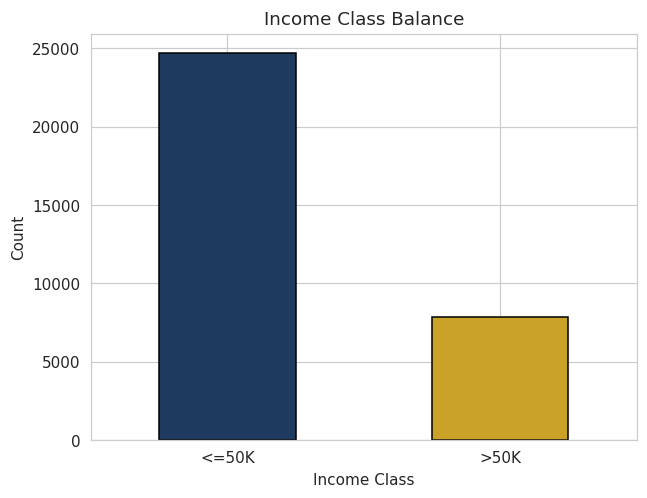

In [13]:
# bar chart of the target class balance
df["income"].value_counts().plot(kind="bar", color=[NAVY, GOLD], edgecolor="black")
plt.title("Income Class Balance")
plt.ylabel("Count")
plt.xlabel("Income Class")
plt.xticks(rotation=0)
plt.show()

The data is imbalanced, about 76 percent at 50K and under and 24 percent over 50K, which is roughly a 3.2 to 1 split. That has two consequences.

First, using plain accuracy is misleading here, because a model that predicts nobody earns over 50K is right about 76 percent of the time while catching zero high earners, which is useless for my lending use case. Precision is the share of predicted high earners who really are high earners, and recall is the share of real high earners the model actually catches. F1 combines those two, so it is much more honest than accuracy when the classes are uneven. ROC-AUC looks at the ranking across all thresholds but can still look flattering when the positive class is small, because a large easy negative class props up the curve. PR-AUC, the area under the precision-recall curve, focuses on the positive class directly and does not get credit for the easy negatives, so it is the most reliable single number for an imbalanced problem like this. That is why my plan leads with PR-AUC and recall and treats accuracy as a secondary number.

Second, handling the imbalance. I plan to train with class weights and with SMOTE oversampling on the training split only, and compare both against training on the raw imbalance. I prefer oversampling the minority class over undersampling the majority, because undersampling would throw away most of the 50K and under rows and lose real information, while oversampling keeps every real row and gives the minority class more weight. I keep the oversampling on the training split only so the validation and test sets stay a real reflection of the true population. I will show the effect of this below when I compare the data before and after preprocessing.

## Feature engineering and dimensionality reduction

Here I add a few features that carry signal for my questions, encode the categoricals, scale the numeric columns, and check whether dimensionality reduction is needed.

In [14]:
# group native country into US, non-US, and Unknown for the fairness question
df["native_region"] = df["native_country"].apply(
    lambda c: "US" if c == "United-States" else ("Unknown" if c == "Unknown" else "non-US")
)
print(df["native_region"].value_counts())

native_region
US         29153
non-US      2802
Unknown      582
Name: count, dtype: int64


In [15]:
# flags for having any capital gain or any capital loss
df["has_capital_gain"] = (df["capital_gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital_loss"] > 0).astype(int)
print(df[["has_capital_gain", "has_capital_loss"]].mean().round(3))

has_capital_gain    0.083
has_capital_loss    0.047
dtype: float64


In [16]:
# bin hours per week into ranges to capture the part time, full time, overtime pattern
df["hours_group"] = pd.cut(df["hours_per_week"], bins=[0, 20, 35, 40, 45, 60, 100],
                           labels=["<=20", "21-35", "36-40", "41-45", "46-60", "60+"])
print(df["hours_group"].value_counts().sort_index())

hours_group
<=20      2924
21-35     3950
36-40    16087
41-45     2441
46-60     6025
60+       1110
Name: count, dtype: int64


Why each of these. native_region turns a column that is 90 percent United States into the US versus non-US split my fairness audit needs, keeping Unknown separate so I am not forcing missing-country people onto one side. has_capital_gain and has_capital_loss exist because capital gain and capital loss are almost always zero with a few very large values, so a plain flag for having any investment income captures the wealth signal without the model over-reacting to the raw dollar amount. hours_group turns hours worked into ranges, which is useful for the education versus hours comparison in H1 since the effect of hours is not a straight line (going from part time to full time matters more than going from 50 to 60 hours).

In [17]:
# one hot encode the categorical columns into numbers the models can use
cat_cols = ["workclass", "marital_status", "occupation", "relationship",
            "race", "sex", "native_region", "hours_group"]
num_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week",
            "has_capital_gain", "has_capital_loss"]
X_encoded = pd.get_dummies(df[cat_cols], drop_first=True).astype(int)
X_encoded = pd.concat([df[num_cols], X_encoded], axis=1)
print("Encoded feature matrix shape:", X_encoded.shape)
X_encoded.head()

Encoded feature matrix shape: (32537, 52)


,age,education_num,capital_gain,capital_loss,hours_per_week,has_capital_gain,has_capital_loss,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,race_Other,race_White,sex_Male,native_region_Unknown,native_region_non-US,hours_group_21-35,hours_group_36-40,hours_group_41-45,hours_group_46-60,hours_group_60+
0,90,9,0,4356,40,0,1,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1,82,9,0,4356,18,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,66,10,0,4356,40,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,54,4,0,3900,40,0,1,0,0,1,...,0,1,0,0,0,0,1,0,0,0
4,41,10,0,3900,40,0,1,0,0,1,...,0,1,0,0,0,0,1,0,0,0


In [18]:
# scale the numeric features so they share the same range
from sklearn.preprocessing import StandardScaler
scale_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
X_scaled = X_encoded.copy()
X_scaled[scale_cols] = StandardScaler().fit_transform(X_scaled[scale_cols])
X_scaled[scale_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,-0.0,1.0,-1.58,-0.78,-0.12,0.69,3.77
education_num,32537.0,0.0,1.0,-3.53,-0.42,-0.03,0.75,2.30
capital_gain,32537.0,-0.0,1.0,-0.15,-0.15,-0.15,-0.15,13.39
capital_loss,32537.0,0.0,1.0,-0.22,-0.22,-0.22,-0.22,10.59
hours_per_week,32537.0,-0.0,1.0,-3.19,-0.04,-0.04,0.37,4.74


After scaling, each numeric feature has a mean near zero and a standard deviation near one, so no single feature dominates just because of its units. In the real pipeline the scaler is fit on the training split only and then applied to validation and test, to avoid leaking information from the test set. I fit it on the full data here only to show what the transformation does for this milestone.

In [19]:
# quick PCA on the scaled numeric features to see if a few components capture most of the variance
from sklearn.decomposition import PCA
pca = PCA().fit(X_scaled[scale_cols])
print("Explained variance per component:", pca.explained_variance_ratio_.round(3))
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_).round(3))

Explained variance per component: [0.259 0.206 0.195 0.177 0.162]
Cumulative: [0.259 0.465 0.66  0.838 1.   ]


The variance is spread fairly evenly across the components, so there is no small set of components that captures almost everything, which is what I would expect given the correlation heatmap shows the numeric features are only weakly related. There are only a handful of numeric features to begin with, and my drivers question (H1) depends on knowing which original feature matters, so reducing them into PCA components would hurt interpretability without buying much. I keep the original features rather than applying PCA.

## Show the impact of preprocessing

Here I compare before and after: the missing values, the class balance after oversampling, and a quick baseline to check the preprocessing actually helped.

In [20]:
# before and after summary of the missing values and the 24 exact duplicates I removed
print("Before: workclass 5.64%, occupation 5.66%, native_country 1.79% missing, 24 exact duplicate rows")
print("After: ", df.isnull().sum().sum(), "missing values, 0 of those exact duplicates left")

Before: workclass 5.64%, occupation 5.66%, native_country 1.79% missing, 24 exact duplicate rows
After:  0 missing values, 0 of those exact duplicates left


In [21]:
# split once so the before and after checks use the same test rows
from sklearn.model_selection import train_test_split
y = df["high_income"]
Xtr, Xte, ytr, yte = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", Xtr.shape[0], "Test:", Xte.shape[0])

Train: 26029 Test: 6508


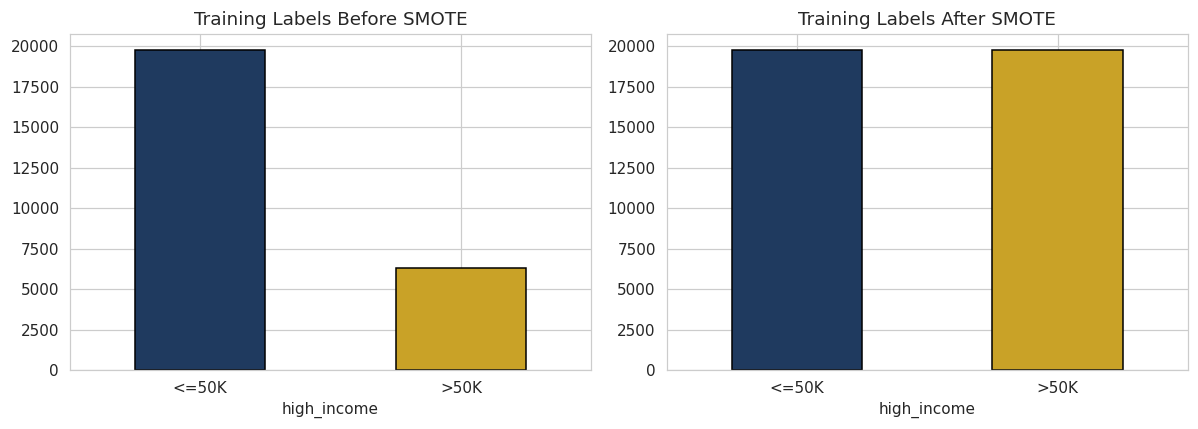

In [22]:
# class balance on the training split before and after SMOTE oversampling
from imblearn.over_sampling import SMOTE
Xtr_bal, ytr_bal = SMOTE(random_state=42).fit_resample(Xtr, ytr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ytr.value_counts().sort_index().plot(kind="bar", ax=axes[0], color=[NAVY, GOLD], edgecolor="black")
axes[0].set_title("Training Labels Before SMOTE")
axes[0].set_xticklabels(["<=50K", ">50K"], rotation=0)
ytr_bal.value_counts().sort_index().plot(kind="bar", ax=axes[1], color=[NAVY, GOLD], edgecolor="black")
axes[1].set_title("Training Labels After SMOTE")
axes[1].set_xticklabels(["<=50K", ">50K"], rotation=0)
plt.tight_layout()
plt.show()

Before SMOTE the training split is imbalanced at about a 3.2 to 1 ratio, the same as the full data. After SMOTE the minority class is oversampled up to a 1 to 1 balance. Only the training split is touched, so the test set still reflects the true population.

To compare the two cleanly I reuse a small performance function from class that prints the accuracy and the per class precision and recall for a fitted model. The recall on the over 50K row is the number I care about here, since that is the share of real high earners the model actually catches.

In [23]:
from sklearn import metrics

def measure_performance(X, y, clf, show_accuracy=True, show_classification_report=True, show_confusion_matrix=True):
  y_pred = clf.predict(X)
  if show_accuracy:
    print("Accuracy:{0:.3f}".format(metrics.accuracy_score(y, y_pred)),"\n")
  if show_classification_report:
    print("Classification report")
    print(metrics.classification_report(y, y_pred),"\n")
  if show_confusion_matrix:
    print("Confusion matrix")
    print(metrics.confusion_matrix(y, y_pred),"\n")

In [24]:
# quick baseline logistic regression on the raw numeric features with the imbalanced data
from sklearn.linear_model import LogisticRegression
raw_num = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
m_before = LogisticRegression(max_iter=1000).fit(Xtr[raw_num], ytr)

In [25]:
# same baseline after scaling, one hot encoding, and SMOTE oversampling
scaler2 = StandardScaler()
Xtr_s, Xte_s = Xtr.copy(), Xte.copy()
Xtr_s[scale_cols] = scaler2.fit_transform(Xtr_s[scale_cols])
Xte_s[scale_cols] = scaler2.transform(Xte_s[scale_cols])
Xtr_s_bal, ytr_s_bal = SMOTE(random_state=42).fit_resample(Xtr_s, ytr)
m_after = LogisticRegression(max_iter=1000).fit(Xtr_s_bal, ytr_s_bal)

In [26]:
# compare the two baselines on the same held out test rows
print("Before preprocessing, raw numeric features on the imbalanced data")
measure_performance(Xte[raw_num], yte, m_before, show_confusion_matrix=False)
print("After scaling, one hot encoding, and SMOTE oversampling")
measure_performance(Xte_s, yte, m_after, show_confusion_matrix=False)

Before preprocessing, raw numeric features on the imbalanced data
Accuracy:0.815 

Classification report
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4940
           1       0.71      0.39      0.50      1568

    accuracy                           0.81      6508
   macro avg       0.77      0.67      0.69      6508
weighted avg       0.80      0.81      0.79      6508
 

After scaling, one hot encoding, and SMOTE oversampling
Accuracy:0.819 

Classification report
              precision    recall  f1-score   support

           0       0.93      0.83      0.87      4940
           1       0.59      0.79      0.68      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.81      0.78      6508
weighted avg       0.85      0.82      0.83      6508
 



This is only a quick sanity check with default settings, not the real modeling, but it makes the point. The raw baseline gets a high accuracy while catching only a small share of the real high earners, which is the trap the imbalance sets. After scaling, encoding, and oversampling, the accuracy stays about the same but the recall on the over 50K row of the report jumps up, meaning the model now catches far more of the real high earners. For my lending use case that is the trade I want. The full modeling, with the three models, hyperparameter tuning, cross validation, and the significance tests, comes in the next milestones.

## Summary statistics

In [27]:
# summary statistics for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
education_num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
capital_gain,32537.0,1078.443741,7387.957424,0.0,0.0,0.0,0.0,99999.0
capital_loss,32537.0,87.368227,403.101833,0.0,0.0,0.0,0.0,4356.0
hours_per_week,32537.0,40.440329,12.346889,1.0,40.0,40.0,45.0,99.0
high_income,32537.0,0.240926,0.427652,0.0,0.0,0.0,0.0,1.0
has_capital_gain,32537.0,0.083351,0.276417,0.0,0.0,0.0,0.0,1.0
has_capital_loss,32537.0,0.046685,0.210967,0.0,0.0,0.0,0.0,1.0


In [28]:
# frequency tables for a few of the key categorical columns
for col in ["workclass", "marital_status", "sex", "native_region"]:
    print(df[col].value_counts(), "\n")

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
Unknown              1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64 

marital_status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64 

sex
Male      21775
Female    10762
Name: count, dtype: int64 

native_region
US         29153
non-US      2802
Unknown      582
Name: count, dtype: int64 



In [29]:
# count outliers in each numeric column using the IQR rule
for col in ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(col, "outliers:", n, "(" + str(round(100 * n / len(df), 1)) + "%)")

age outliers: 142 (0.4%)
education_num outliers: 1193 (3.7%)
capital_gain outliers: 2712 (8.3%)
capital_loss outliers: 1519 (4.7%)
hours_per_week outliers: 9002 (27.7%)


I use the IQR rule rather than z-scores to flag outliers, because z-scores assume a roughly normal, symmetric distribution, and capital gain, capital loss, and hours worked are all heavily skewed, so a z-score would mislabel a lot of ordinary points. The IQR rule does not assume normality and just looks at how far a value sits from the middle half of the data.

The columns it flags the most are capital gain and capital loss, which is expected since almost everyone is at zero and a few people have large investment income, so any nonzero value looks like an outlier. Those are real values, not data errors, so I do not remove them. Removing real high earners would directly bias the income analysis, and tree models like XGBoost handle these skewed values without any trimming. This is also the reason I built the capital gain and loss flags earlier during feature engineering.

## Visualizations

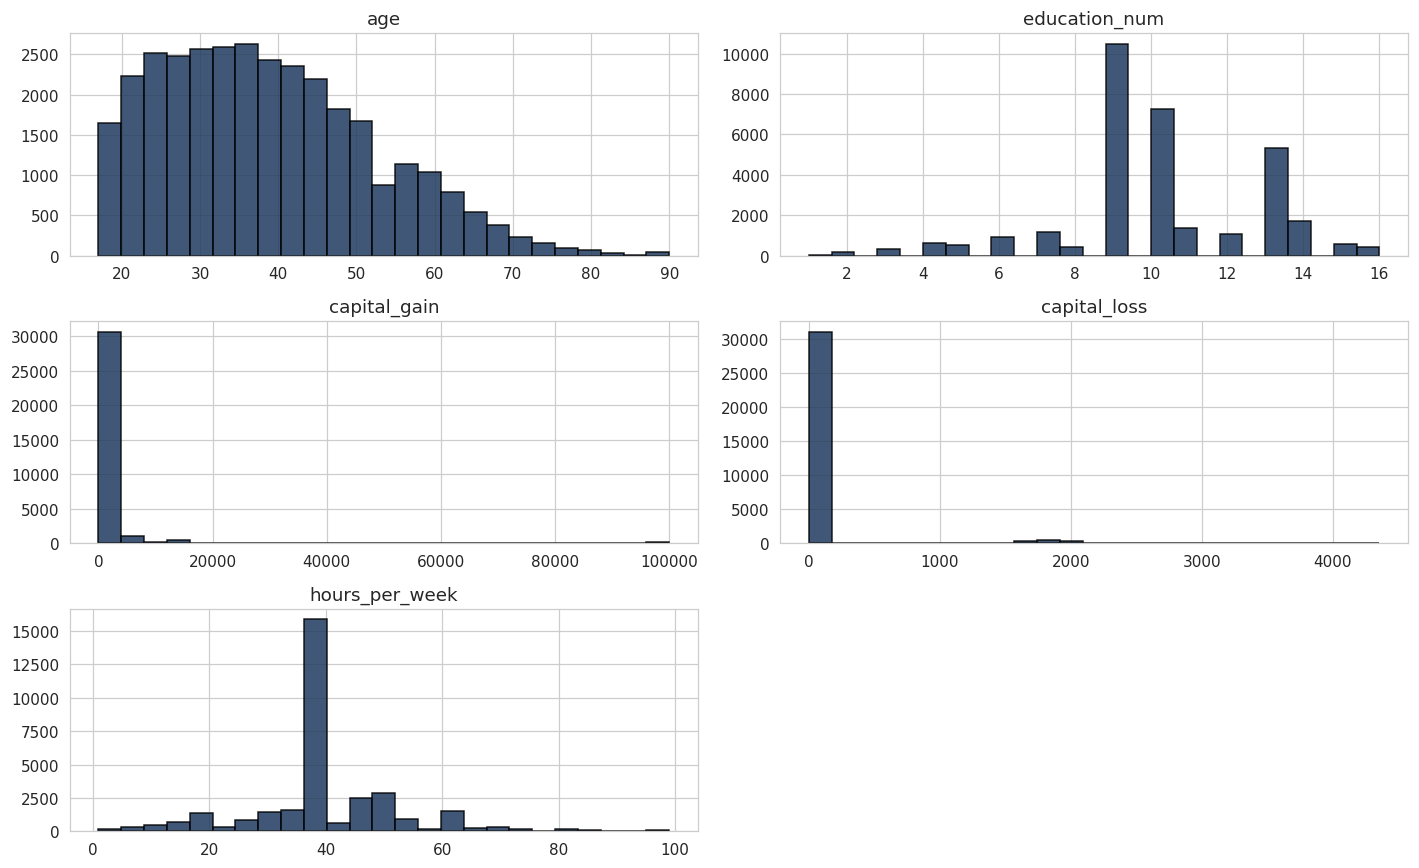

In [30]:
# histograms of the numeric features to see their distributions
df[["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]].hist(
    figsize=(13, 8), bins=25, color=NAVY, edgecolor="black", alpha=0.85)
plt.tight_layout()
plt.show()

Age is spread out and roughly bell shaped with a mean near 38. Education in years is discrete and clusters around 9 to 10, which is high school. Hours per week piles up hard at 40. Capital gain and capital loss are almost entirely zero with a few large values, which matches the outlier check and is why I made the binary flags.

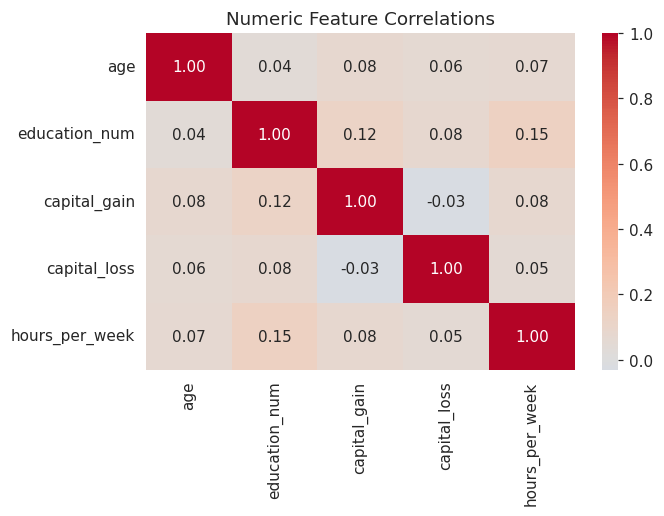

In [31]:
# correlation heatmap of the numeric features
num5 = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
sns.heatmap(df[num5].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Numeric Feature Correlations")
plt.tight_layout()
plt.show()

Every off-diagonal correlation is small, so there is no strong multicollinearity among the numeric features. That matters for the logistic regression baseline, because heavily correlated inputs make its coefficients unstable and hard to read, and my drivers question in H1 leans on those coefficients. With correlations this low I do not need to drop any numeric feature for that reason.

/tmp/ipykernel_1339/1028273427.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="income", y="education_num", palette=[NAVY, GOLD])


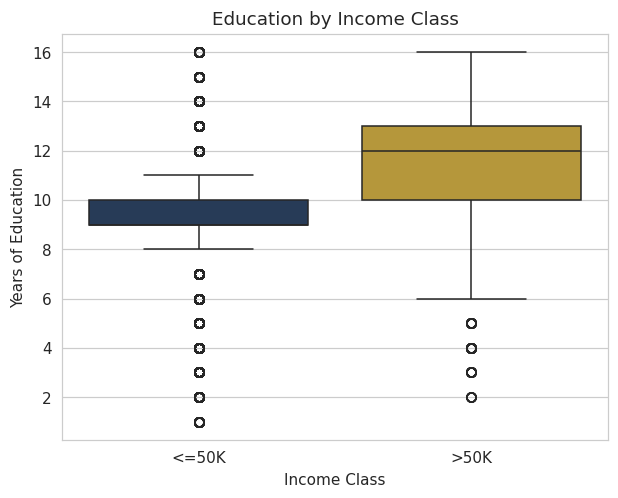

In [32]:
# boxplot of education for each income class
sns.boxplot(data=df, x="income", y="education_num", palette=[NAVY, GOLD])
plt.title("Education by Income Class")
plt.xlabel("Income Class")
plt.ylabel("Years of Education")
plt.show()

The over 50K group sits clearly higher on the education scale than the 50K and under group, so years of education separates the two classes on its own. There is still a lot of overlap between the boxes, which is why education alone cannot predict income perfectly and the models use the other features too.

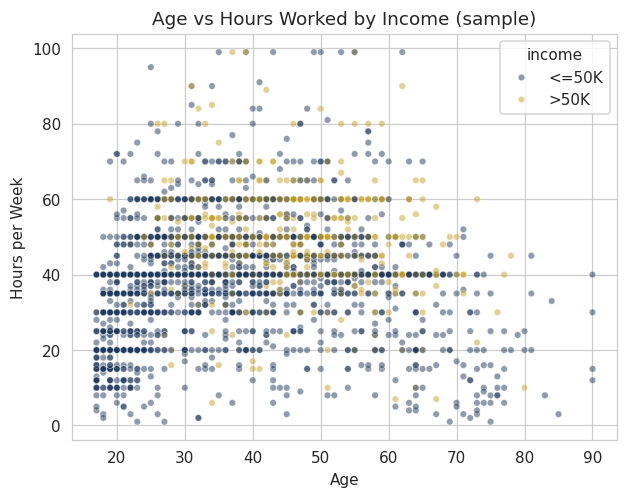

In [33]:
# scatter of age against hours worked, colored by income class
sub = df.sample(4000, random_state=42)
sns.scatterplot(data=sub, x="age", y="hours_per_week", hue="income",
                palette=[NAVY, GOLD], alpha=0.5, s=18)
plt.title("Age vs Hours Worked by Income (sample)")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()

This is a sample of 4,000 rows so the points are readable. The over 50K points cluster in middle age and around or above full time hours, while the 50K and under points are more common among the young and among people working fewer hours. The two classes overlap heavily, which again says no single pair of features cleanly splits them.

## Patterns tied to my hypotheses

This is the part that ties the exploration to the three questions. I go through H1, H2, and H3 in turn and ask what each plot actually says about the hypothesis, including where it does not fully settle the question.

### H1: is education a stronger driver than hours worked

H1 says education level drives the over 50K prediction more than hours worked. I cannot fully answer that with EDA, since that needs feature importance on a trained model, but I can see how cleanly each feature separates the classes on its own, which is a first hint.

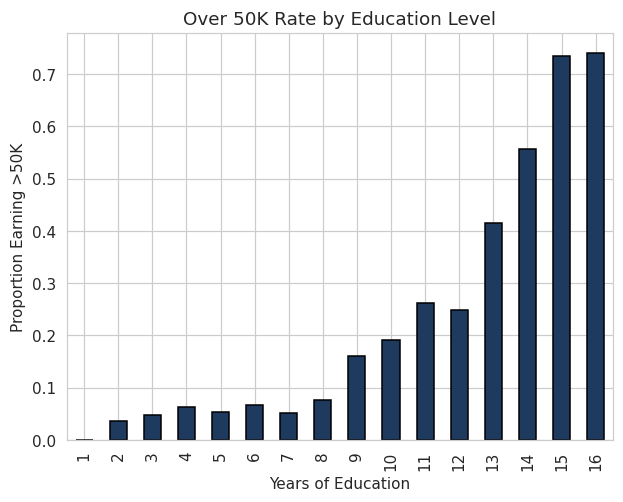

In [34]:
# share earning over 50K at each education level
edu_rate = df.groupby("education_num")["high_income"].mean()
edu_rate.plot(kind="bar", color=NAVY, edgecolor="black")
plt.title("Over 50K Rate by Education Level")
plt.xlabel("Years of Education")
plt.ylabel("Proportion Earning >50K")
plt.show()

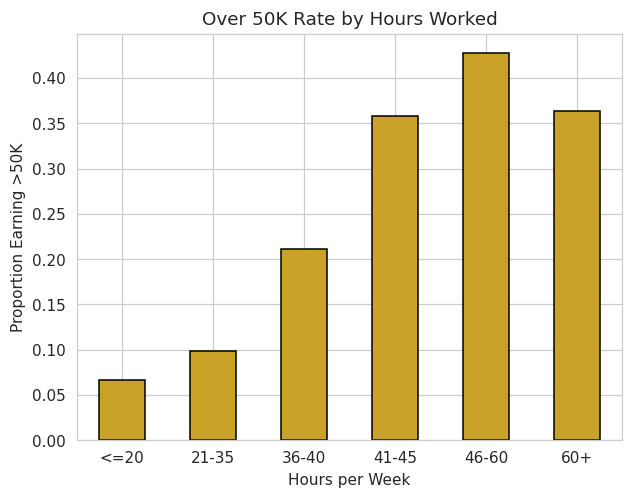

In [35]:
# share earning over 50K in each hours group
hrs_rate = df.groupby("hours_group", observed=True)["high_income"].mean()
hrs_rate.plot(kind="bar", color=GOLD, edgecolor="black")
plt.title("Over 50K Rate by Hours Worked")
plt.xlabel("Hours per Week")
plt.ylabel("Proportion Earning >50K")
plt.xticks(rotation=0)
plt.show()

In [36]:
# how wide the over 50K rate spread is for each feature, a wider spread separates the classes better alone
print("Education rate range:", round(edu_rate.min(), 3), "to", round(edu_rate.max(), 3),
      "spread", round(edu_rate.max() - edu_rate.min(), 3))
print("Hours rate range:   ", round(hrs_rate.min(), 3), "to", round(hrs_rate.max(), 3),
      "spread", round(hrs_rate.max() - hrs_rate.min(), 3))

Education rate range: 0.0 to 0.741 spread 0.741
Hours rate range:    0.067 to 0.428 spread 0.361


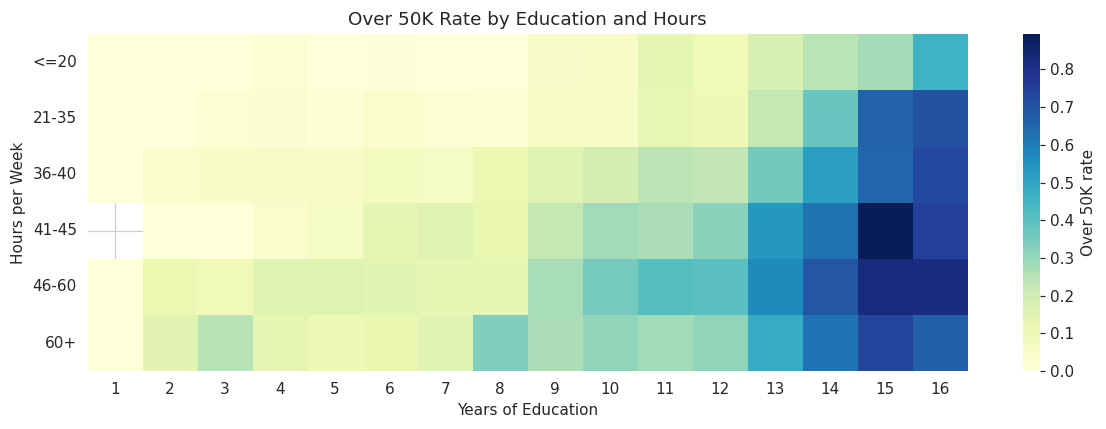

In [37]:
# over 50K rate across education and hours together, to look for an interaction
piv = df.pivot_table(index="hours_group", columns="education_num",
                     values="high_income", aggfunc="mean", observed=True)
plt.figure(figsize=(11, 4))
sns.heatmap(piv, cmap="YlGnBu", annot=False, cbar_kws={"label": "Over 50K rate"})
plt.title("Over 50K Rate by Education and Hours")
plt.xlabel("Years of Education")
plt.ylabel("Hours per Week")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Education shows a steady, clean climb in the over 50K rate from the lowest levels up to the highest, and the spread it produces is much wider than the spread from hours worked. Hours also trends up, but it flattens out at the top, more hours past full time does not keep raising the rate much, and the effect is smaller overall. The heatmap shows that the highest over 50K rates need both high education and full time or more hours, but education moves the rate more strongly from top to bottom than hours does from left to right.

This lines up with H1 as a first hint: education looks like the stronger single driver. I am careful not to call it settled, because this is a one feature at a time view and education is correlated with other features like occupation and marital status. The real test is the coefficient comparison and permutation importance on the trained model in the next milestone, with a bootstrap interval on the gap.

### H2: the base-rate gap across nativity

H2 is the fairness question. I am not testing a model here, I am showing the base-rate gap across nativity that the models will later be audited against, so the fairness audit knows where to look.

In [38]:
# group sizes and over 50K rate for each native region
region_n = df["native_region"].value_counts()
region_rate = df.groupby("native_region")["high_income"].mean()
print(pd.DataFrame({"count": region_n, "over_50k_rate": region_rate.round(3)}))

               count  over_50k_rate
native_region                      
US             29153          0.246
Unknown          582          0.251
non-US          2802          0.187


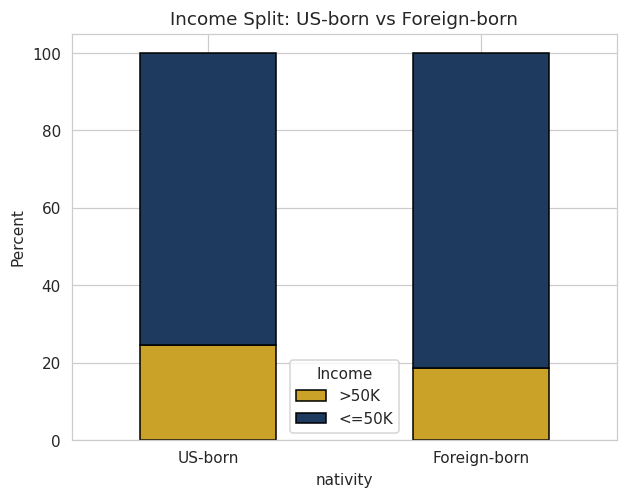

In [39]:
# full income split for US-born vs foreign-born
nat = df[df["native_region"].isin(["US", "non-US"])].copy()
nat["nativity"] = nat["native_region"].map({"US": "US-born", "non-US": "Foreign-born"})
split = (nat.groupby("nativity")["income"].value_counts(normalize=True)
         .unstack().reindex(["US-born", "Foreign-born"]) * 100)
split[[">50K", "<=50K"]].plot(kind="bar", stacked=True, color=[GOLD, NAVY], edgecolor="black")
plt.title("Income Split: US-born vs Foreign-born")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.show()

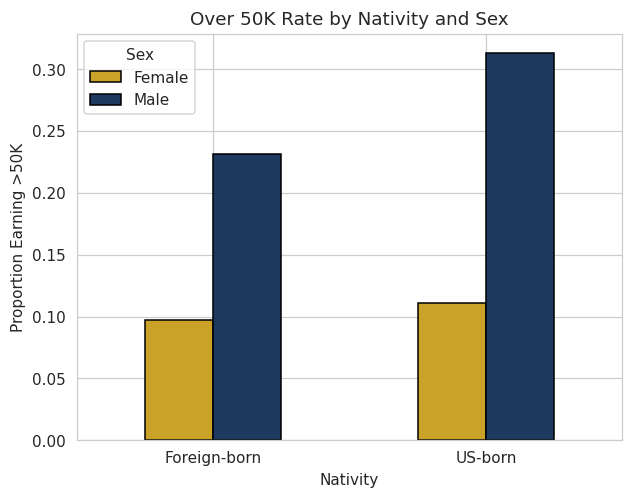

In [40]:
# over 50K rate for US-born vs foreign-born, split further by sex so nativity is not looked at alone
tab = nat.groupby(["nativity", "sex"])["high_income"].mean().unstack()
tab.plot(kind="bar", color=[GOLD, NAVY], edgecolor="black")
plt.title("Over 50K Rate by Nativity and Sex")
plt.ylabel("Proportion Earning >50K")
plt.xlabel("Nativity")
plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.show()

US-born people earn over 50K at a higher rate than foreign-born people, about 25 percent against 19 percent in this data. That base-rate gap is what H2 is about. If a model just learns this gap, it can end up missing real high earners among foreign-born people, which shows up as a higher false negative rate, or equally a lower recall, for that group. The recall gap between the two groups is the quantity my fairness audit measures for each model, and H2 predicts XGBoost will have the smallest gap.

Breaking the same rate out by sex shows the nativity gap is not an isolated effect. Men earn over 50K at a higher rate than women in both nativity groups, so sex and nativity both move the base rate, which is why the plan audits sex and race alongside nativity rather than looking at nativity by itself. This is only the setup, the actual per-group recall gaps and their bootstrap intervals come once the models are trained.

### H3: what the EDA says about model choice

H3 says XGBoost will classify better than the logistic baseline and the MLP. EDA cannot test that, but it can show whether the data has the kind of non-linear and threshold patterns that tree and network models pick up better than a straight linear model, which is the reason to expect a gap.

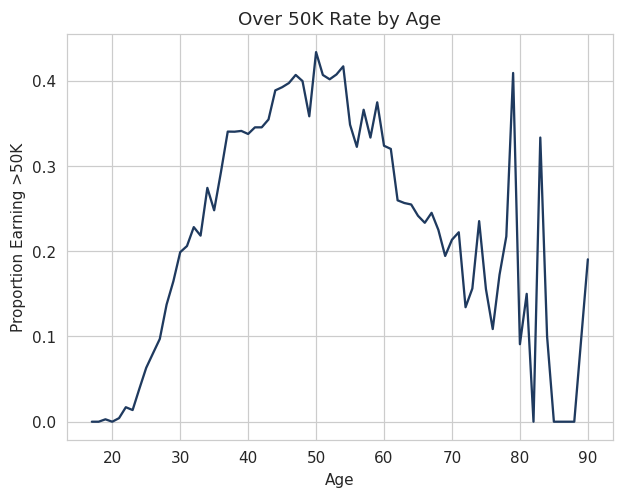

In [41]:
# over 50K rate across age, to show the relationship is not a straight line
age_rate = df.groupby("age")["high_income"].mean()
age_rate.plot(color=NAVY)
plt.title("Over 50K Rate by Age")
plt.xlabel("Age")
plt.ylabel("Proportion Earning >50K")
plt.show()

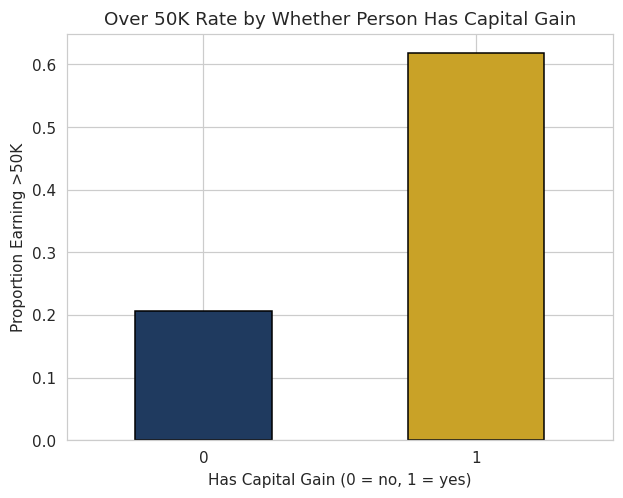

In [42]:
# over 50K rate for people with vs without any capital gain
df.groupby("has_capital_gain")["high_income"].mean().plot(
    kind="bar", color=[NAVY, GOLD], edgecolor="black")
plt.title("Over 50K Rate by Whether Person Has Capital Gain")
plt.xlabel("Has Capital Gain (0 = no, 1 = yes)")
plt.ylabel("Proportion Earning >50K")
plt.xticks(rotation=0)
plt.show()

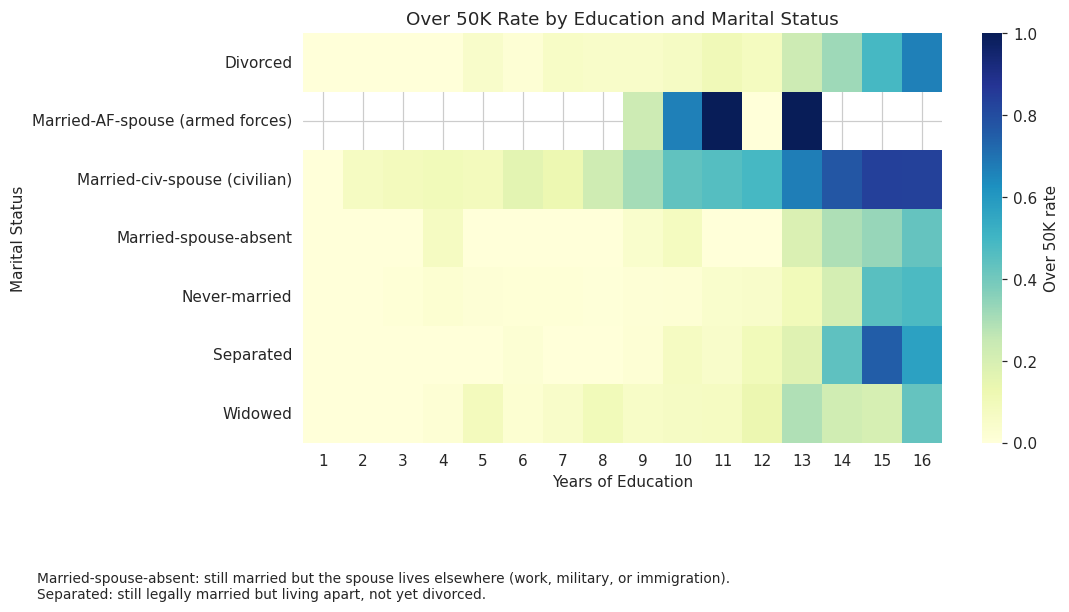

In [43]:
# over 50K rate across education and marital status together, another interaction check
piv2 = df.pivot_table(index="marital_status", columns="education_num",
                      values="high_income", aggfunc="mean")

# spell out the two abbreviated marital categories on the axis
label_map = {
    "Married-AF-spouse": "Married-AF-spouse (armed forces)",
    "Married-civ-spouse": "Married-civ-spouse (civilian)",
}
ylabels = [label_map.get(m, m) for m in piv2.index]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(piv2, cmap="YlGnBu", cbar_kws={"label": "Over 50K rate"}, ax=ax)
ax.set_title("Over 50K Rate by Education and Marital Status")
ax.set_xlabel("Years of Education")
ax.set_ylabel("Marital Status")
ax.set_yticklabels(ylabels, rotation=0)

# note for the two categories that are easy to misread
note = ("Married-spouse-absent: still married but the spouse lives elsewhere (work, military, or immigration).\n"
        "Separated: still legally married but living apart, not yet divorced.")
fig.subplots_adjust(left=0.24, bottom=0.26)
fig.text(0.02, 0.02, note, ha="left", va="bottom", fontsize=9)
plt.show()

A few things here point toward the tree and network models having room to beat a plain linear model, which is what H3 predicts.

The over 50K rate by age is a clear curve, not a line. It rises through the working years, peaks in middle age, and then falls again for the oldest ages. A linear model reads age as a single straight up or down effect, so it cannot capture that rise and fall on its own, while a tree or a network can.

Having any capital gain flips the over 50K rate dramatically, from a low base rate to a very high one. That is a threshold effect, and it is exactly why I built the flag, but it also shows the kind of sharp cutoff that tree splits handle naturally.

The education by marital status heatmap shows the over 50K rate depends on the two features together, not just each one added up. Married people with high education reach much higher rates than either feature alone would suggest, which is an interaction. Logistic regression only gets interactions if I add them by hand, while XGBoost and the MLP find them on their own.

So the EDA is consistent with H3: there are non-linear and interaction patterns in the data that give the more flexible models something to exploit. Whether XGBoost actually wins on PR-AUC and F1, and whether the gap is significant, is the McNemar and bootstrap test in the modeling milestone.

### What the EDA says about each hypothesis so far

H1: education produces a wider and cleaner spread in the over 50K rate than hours worked, which is an early hint in favor of education being the stronger driver, to be confirmed with feature importance on the trained model.

H2: there is a real base-rate gap in the over 50K rate between US-born and foreign-born people, and it holds up alongside sex, which is the gap the fairness audit will measure as a recall gap for each model.

H3: the data has non-linear effects (age) and interactions (education with marital status) and threshold effects (capital gain) that flexible models can use, which is consistent with expecting XGBoost to classify better than the linear baseline.

I also looked for anything in the EDA that cut against these three, and nothing did. The main caution is the heavy class overlap on any single feature, which limits how strong each hint is but does not point any of the hypotheses the other way.

### How I used an LLM for this assignment

I used an LLM to help create some of the visualizations in this notebook and also to help create some markdown cells in this notebook so I could correctly interpret some of the visualizations in this notebook too. I wrote and edited the analysis myself and confirmed the numbers by running the notebook top to bottom. I finally used an LLM to confirm that I covered every part of the instructions for this notebook to ensure it is fully complete.